In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/drive/MyDrive/Healthcare Project/cleaned_data.csv')

In [58]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,WaitingDays,AppointmentDayName,Status,Gender_Label
0,2.987250e+13,5642903,0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,Friday,Showed Up,Female
1,5.589978e+14,5642503,1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,Friday,Showed Up,Male
2,4.262962e+12,5642549,0,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,Friday,Showed Up,Female
3,8.679512e+11,5642828,0,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,Friday,Showed Up,Female
4,8.841186e+12,5642494,0,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,Friday,Showed Up,Female


In [15]:
#For convient visualization
df['Status'] = df['No-show'].map({0: 'Showed Up', 1: 'No-Show'})
df['Gender_Label']=df['Gender'].map({1:'Male',0:'Female'})

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110521 entries, 0 to 110520
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   PatientId           110521 non-null  float64            
 1   AppointmentID       110521 non-null  int64              
 2   Gender              110521 non-null  int64              
 3   ScheduledDay        110521 non-null  datetime64[ns, UTC]
 4   AppointmentDay      110521 non-null  datetime64[ns, UTC]
 5   Age                 110521 non-null  int64              
 6   Neighbourhood       110521 non-null  object             
 7   Scholarship         110521 non-null  int64              
 8   Hypertension        110521 non-null  int64              
 9   Diabetes            110521 non-null  int64              
 10  Alcoholism          110521 non-null  int64              
 11  Handicap            110521 non-null  int64              
 12  SMS_received    

In [10]:
df['AppointmentDay']=pd.to_datetime(df['AppointmentDay'])
df['ScheduledDay']=pd.to_datetime(df['ScheduledDay'])

In [8]:
# Setting a cohesive color palette and style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Univariate anaysis

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110521 entries, 0 to 110520
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   PatientId           110521 non-null  float64            
 1   AppointmentID       110521 non-null  int64              
 2   Gender              110521 non-null  int64              
 3   ScheduledDay        110521 non-null  datetime64[ns, UTC]
 4   AppointmentDay      110521 non-null  datetime64[ns, UTC]
 5   Age                 110521 non-null  int64              
 6   Neighbourhood       110521 non-null  object             
 7   Scholarship         110521 non-null  int64              
 8   Hypertension        110521 non-null  int64              
 9   Diabetes            110521 non-null  int64              
 10  Alcoholism          110521 non-null  int64              
 11  Handicap            110521 non-null  int64              
 12  SMS_received    

In [46]:
numeric=['Age','WaitingDays']
categorical=['Gender_Label','AppointmentDayName','Status']
date=['ScheduledDay','AppointmentDay']

In [29]:
summary=df[numeric].describe()
summary=summary.T
summary['median']=df[numeric].median()
summary['IQR']=summary['75%'] - summary['25%']
summary['skewness']=df[numeric].skew()
summary

,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Age,110521.0,37.089386,23.109885,0.0,18.0,37.0,55.0,115.0,37.0,37.0,0.121609
WaitingDays,110521.0,10.184345,15.255153,0.0,0.0,4.0,15.0,179.0,4.0,15.0,2.665885


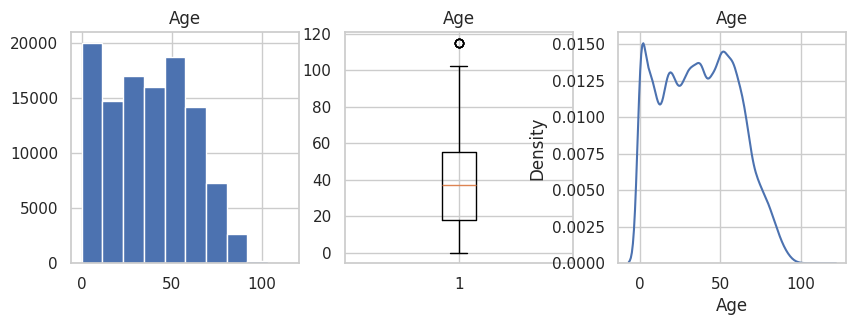

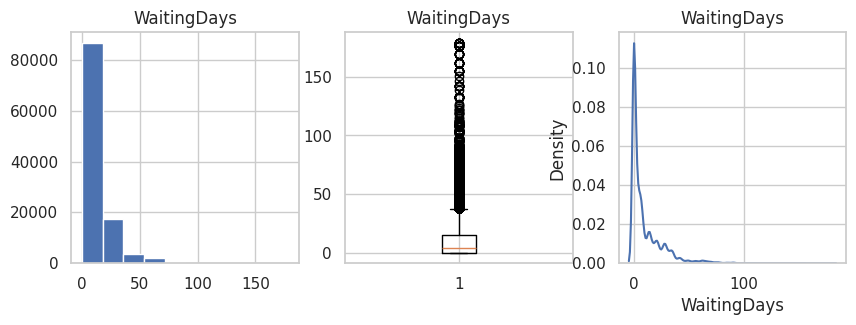

In [34]:
for col in numeric:
  plt.figure(figsize=(10,3))
  plt.subplot(1,3,1)
  plt.hist(df[col])
  plt.title(col)

  plt.subplot(1,3,2)
  plt.boxplot(df[col])
  plt.title(col)

  plt.subplot(1,3,3)
  sns.kdeplot(df[col])
  plt.title(col)

  plt.show()


In [42]:
from numpy import floor
# outliers detection

Q1 = df['WaitingDays'].quantile(0.25)
Q3 = df['WaitingDays'].quantile(0.75)

IQR= Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = floor(Q3 + 1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -22.5
Upper Bound: 37.0


In [45]:
outliers = df[(df['WaitingDays'] < lower_bound) | (df['WaitingDays'] > upper_bound)]

outliers.shape

(5803, 18)

Distrubution of values Gender_Label
Female    71836
Male      38685
Name: count, dtype: int64


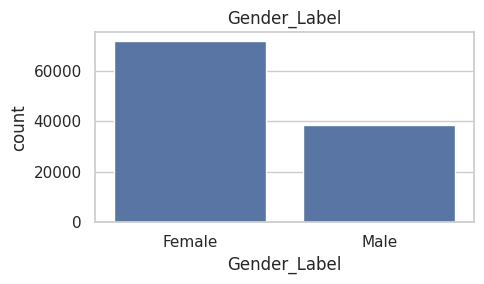

Distrubution of values AppointmentDayName
Wednesday    25866
Tuesday      25638
Monday       22713
Friday       19019
Thursday     17246
Saturday        39
Name: count, dtype: int64


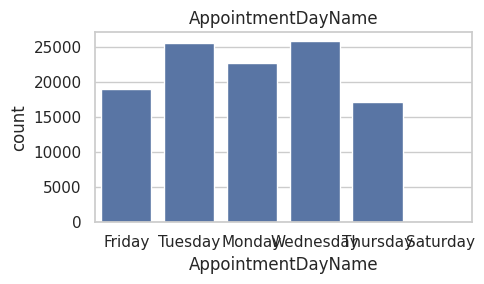

Distrubution of values Status
Showed Up    88207
No-Show      22314
Name: count, dtype: int64


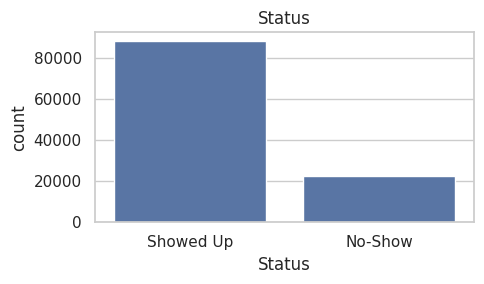

In [56]:
# categorical variables
for col in categorical:
  plt.figure(figsize=(5,3))
  print("Distrubution of values",df[col].value_counts())
  sns.countplot(data=df,x=df[col])
  plt.title(col)
  plt.tight_layout()
  plt.show()

min :2015-11-10 07:13:56+00:00
max :2016-06-08 20:07:23+00:00

date range :211 days 12:53:27


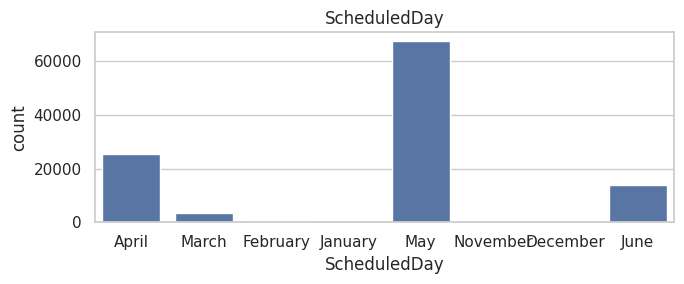

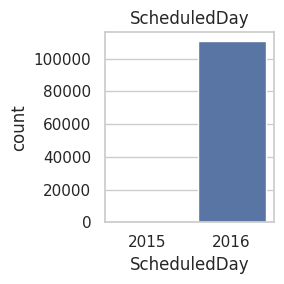

min :2016-04-29 00:00:00+00:00
max :2016-06-08 00:00:00+00:00

date range :40 days 00:00:00


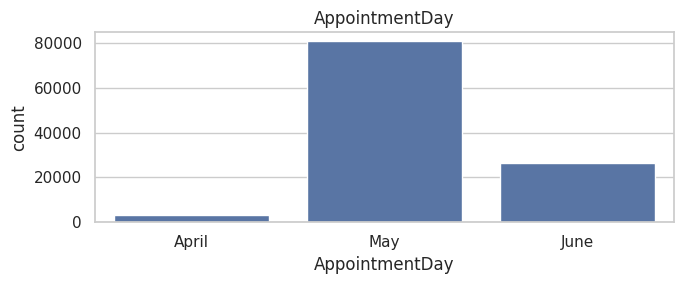

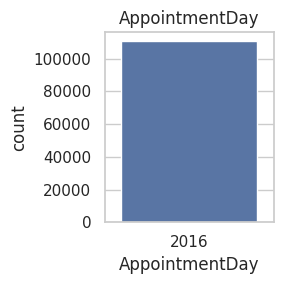

In [72]:
#Date variables

for col in date:
  print(f'min :{df[col].min()}\nmax :{df[col].max()}\n')
  print(f'date range :{df[col].max()-df[col].min()}')

  plt.figure(figsize=(7,3))
  sns.countplot(data=df,x=df[col].dt.month_name())
  plt.title(col)
  plt.tight_layout()
  plt.show()

  plt.figure(figsize=(3,3))
  sns.countplot(data=df,x=df[col].dt.year)
  plt.title(col)
  plt.tight_layout()
  plt.show()


Bivariate analysis

<Axes: >

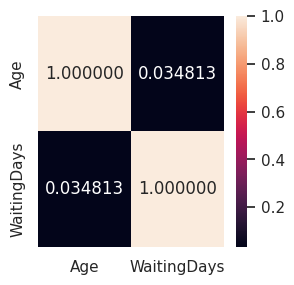

In [76]:
#numerical values
corr=df[numeric].corr
plt.figure(figsize=(3,3))
sns.heatmap(corr(),annot=True,fmt='2f')


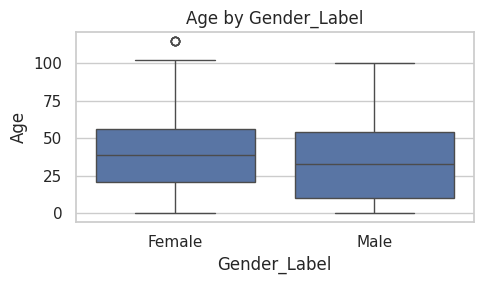

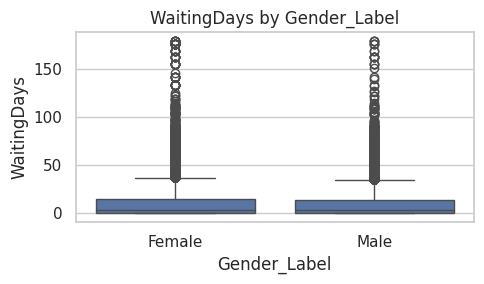

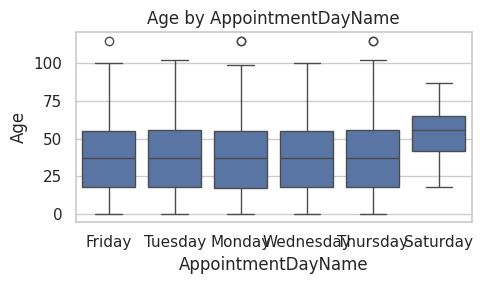

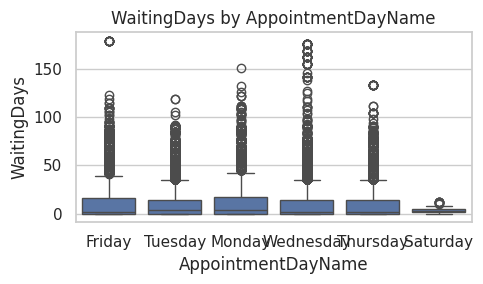

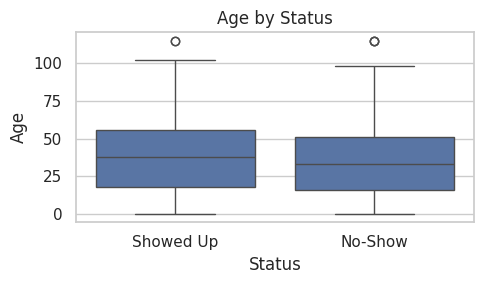

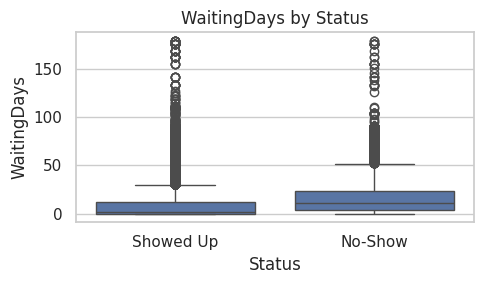

In [79]:
#numerical - categorical
for col in categorical:
  for num in numeric:
    plt.figure(figsize=(5,3))
    sns.boxplot(data=df,x=col,y=num)
    plt.title(f'{num} by {col}')
    plt.tight_layout()
    plt.show()

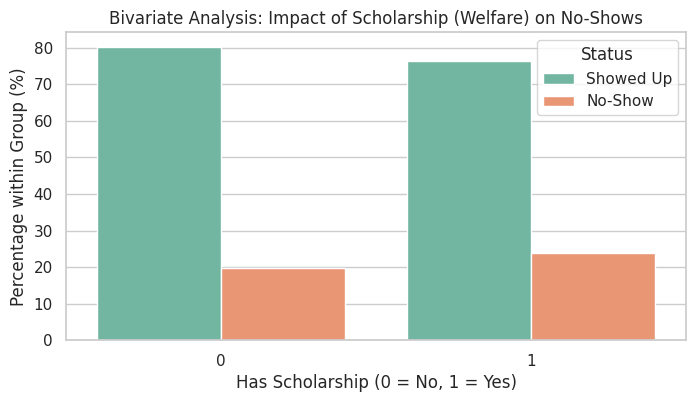

In [80]:
#categorical - categorical

plt.figure(figsize=(8, 4))
# Normalize the counts to show percentage breakdown within each group
scholarship_pct = (df.groupby('Scholarship')['Status']
                   .value_counts(normalize=True)
                   .rename('Percentage')
                   .mul(100)
                   .reset_index())

sns.barplot(x='Scholarship', y='Percentage', hue='Status', data=scholarship_pct, palette='Set2')
plt.title('Bivariate Analysis: Impact of Scholarship (Welfare) on No-Shows')
plt.xlabel('Has Scholarship (0 = No, 1 = Yes)')
plt.ylabel('Percentage within Group (%)')
plt.show()


Multivariae analysis

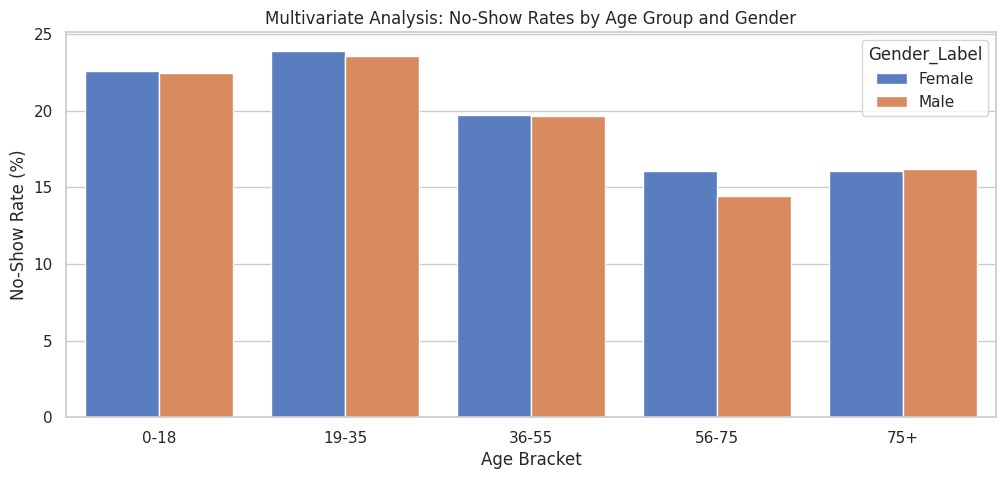

In [82]:
plt.figure(figsize=(12, 5))
# Create age groups to make the visualization clean
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 18, 35, 55, 75, 120], labels=['0-18', '19-35', '36-55', '56-75', '75+'])
gender_map = {0: 'Female', 1: 'Male'}
df['Gender_Label'] = df['Gender'].map(gender_map)

# Calculate no-show rate for combinations
multi_analysis = df.groupby(['AgeGroup', 'Gender_Label'], observed=False)['No-show'].mean().reset_index()
multi_analysis['No-show_Rate_%'] = multi_analysis['No-show'] * 100

sns.barplot(x='AgeGroup', y='No-show_Rate_%', hue='Gender_Label', data=multi_analysis, palette='muted')
plt.title('Multivariate Analysis: No-Show Rates by Age Group and Gender')
plt.xlabel('Age Bracket')
plt.ylabel('No-Show Rate (%)')
plt.show()

Summary Insights:

- Operational Bottleneck: Clinics are heavily overloaded on Mondays, Tuesdays, and Wednesdays. We should recommend offering administrative scheduling incentives to distribute the patient load to Thursdays and Fridays.

- Target Demographic Risk: Young adults (ages 19–35) and welfare scholarship recipients are your highest-risk groups. Instead of standard text blasts, these two segments should receive phone call follow-ups.

- The Outlier Strategy: Over 9,000 appointments have extreme wait times exceeding 37 days. The data shows that the longer a patient waits, the more they disengage. The clinic should introduce an automated mandatory "re-confirmation" prompt 7 days before any outlier appointment to clear dead slots.